## Load results
Allow loading results from multiple folders

In [1]:
import os
import pickle

def load_result_dicts(dirs, whitelist=None, blacklist=None, equivalence_dict=None):
    """
    Combine results from multiple sweep directories
    """

    all_dicts = {}
    for dir_path in dirs:
        print(f"Loading results from {dir_path}")
        # get names of all children of dir_path, which are format *dict.pkl
        all_files = os.listdir(dir_path)
        dict_files = [f for f in all_files if f.endswith('dict.pkl')]
        for f in dict_files:
            shortened_name = f.split('_dict.pkl')[0]
            if shortened_name not in all_dicts:
                all_dicts[shortened_name] = {}

            d = pickle.load(open(os.path.join(dir_path, f), 'rb')) # d is a dictionary of {model_name: model_results}
            print(f"Loading from {dir_path}/{f}")
            if shortened_name in all_dicts:
                # update the all_dicts[f] with all the keys in d
                # for k in d:
                #     all_dicts[shortened_name][k] = d[k]
                for k in d:
                    model_name = k
                    if equivalence_dict is not None and k in equivalence_dict:
                        model_name = equivalence_dict[k]
                    if whitelist is not None and model_name not in whitelist:
                        continue
                    if blacklist is not None and model_name in blacklist:
                        continue
                    if model_name in all_dicts[shortened_name]:
                        all_dicts[shortened_name][model_name].update(d[k])
                    else:
                        all_dicts[shortened_name][model_name] = d[k]
                # all_dicts[shortened_name].update(d)
            else:
                # add it to the all_dicts
                # all_dicts[shortened_name] = d
                for k in d:
                    model_name = k
                    if equivalence_dict is not None and k in equivalence_dict:
                        model_name = equivalence_dict[k]
                    if whitelist is not None and model_name not in whitelist:
                        continue
                    if blacklist is not None and model_name in blacklist:
                        continue
                    all_dicts[shortened_name][model_name] = d[k]
                
    return all_dicts



In [7]:
all_dicts = load_result_dicts(["results/llama-lat-less-noise", "results/llama-lat-less-noise-2", "results/pca-ultrachat-final-sweep-sft_type=harmless"], whitelist=["WHP", "WHP_Replication", "WHP_All_Coefs", 'PCA_L10_Eps0.1', 'PCA_L15_Eps0.1', 'PCA_L20_Eps0.1', 'PCA_L10_Eps1.0', 'PCA_L15_Eps1.0', 'PCA_L20_Eps1.0', 'PCA_L10_Eps10.0', 'PCA_L15_Eps10.0', 'PCA_L20_Eps10.0', "WHP_Original"], equivalence_dict={"WHP_Original": "WHP"})

Loading results from results/llama-lat-less-noise
Loading from results/llama-lat-less-noise/capability_dict.pkl
Loading from results/llama-lat-less-noise/familiarity_dict.pkl
Loading from results/llama-lat-less-noise/spanish_familiarity_dict.pkl
Loading from results/llama-lat-less-noise/summary_style_dict.pkl
Loading from results/llama-lat-less-noise/trivia_dict.pkl
Loading results from results/llama-lat-less-noise-2
Loading from results/llama-lat-less-noise-2/capability_dict.pkl
Loading from results/llama-lat-less-noise-2/dan_adversarial_dict.pkl
Loading from results/llama-lat-less-noise-2/familiarity_dict.pkl
Loading from results/llama-lat-less-noise-2/full_capability_dict.pkl
Loading from results/llama-lat-less-noise-2/spanish_familiarity_dict.pkl
Loading from results/llama-lat-less-noise-2/summary_style_dict.pkl
Loading from results/llama-lat-less-noise-2/trivia_dict.pkl
Loading results from results/pca-ultrachat-final-sweep-sft_type=harmless
Loading from results/pca-ultrachat-fina

In [8]:
all_dicts.keys()

dict_keys(['capability', 'familiarity', 'spanish_familiarity', 'summary_style', 'trivia', 'dan_adversarial', 'full_capability', 'text_lines'])

In [9]:
print(all_dicts['familiarity'].keys())
print(all_dicts['full_capability'].keys())
print(all_dicts['summary_style'].keys())
print(all_dicts['spanish_familiarity'].keys())
print(all_dicts['dan_adversarial'].keys())
print(all_dicts['text_lines'].keys())

dict_keys(['WHP', 'WHP_Replication', 'WHP_All_Coefs', 'PCA_L10_Eps0.1', 'PCA_L15_Eps0.1', 'PCA_L20_Eps0.1', 'PCA_L10_Eps1.0', 'PCA_L15_Eps1.0', 'PCA_L20_Eps1.0', 'PCA_L10_Eps10.0', 'PCA_L15_Eps10.0', 'PCA_L20_Eps10.0'])
dict_keys(['WHP', 'WHP_Replication', 'WHP_All_Coefs', 'PCA_L10_Eps0.1', 'PCA_L15_Eps0.1', 'PCA_L20_Eps0.1', 'PCA_L10_Eps1.0', 'PCA_L15_Eps1.0', 'PCA_L20_Eps1.0', 'PCA_L10_Eps10.0', 'PCA_L15_Eps10.0', 'PCA_L20_Eps10.0'])
dict_keys(['WHP', 'WHP_Replication', 'WHP_All_Coefs', 'PCA_L10_Eps0.1', 'PCA_L15_Eps0.1', 'PCA_L20_Eps0.1', 'PCA_L10_Eps1.0', 'PCA_L15_Eps1.0', 'PCA_L20_Eps1.0', 'PCA_L10_Eps10.0', 'PCA_L15_Eps10.0', 'PCA_L20_Eps10.0'])
dict_keys(['WHP', 'WHP_Replication', 'WHP_All_Coefs', 'PCA_L10_Eps0.1', 'PCA_L15_Eps0.1', 'PCA_L20_Eps0.1', 'PCA_L10_Eps1.0', 'PCA_L15_Eps1.0', 'PCA_L20_Eps1.0', 'PCA_L10_Eps10.0', 'PCA_L15_Eps10.0', 'PCA_L20_Eps10.0'])
dict_keys(['WHP_All_Coefs', 'PCA_L10_Eps0.1', 'PCA_L15_Eps0.1', 'PCA_L20_Eps0.1', 'PCA_L10_Eps1.0', 'PCA_L15_Eps1.0', 'P

# Analyzing LAT familiarity + Adversarial Testing results

In [10]:
def get_familiarity_score(dict):
    try:
        overall_dict = {}
        for key in dict:
            total_responses = dict[key].get(0) + dict[key].get(1) + dict[key].get(2) + dict[key].get(3)
            total_correct = dict[key].get(2) / 5 + dict[key].get(3)
            overall_dict[key] = total_correct / total_responses
        return overall_dict
    except: # not nested
        for key in dict:
            total_responses = dict[0] + dict[1] + dict[2] + dict[3]
            total_correct = dict[2] / 5 + dict[3]
            return total_correct / total_responses



In [11]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# save_dir = "results/llama-lat-adversarial-testing"
# save_dir = "results/llama-lat-WHP-baselines-2"
# with open(f"{save_dir}/capability_dict.pkl", "rb") as f:
#     capability_dict = pickle.load(f)

capability_dict = all_dicts['full_capability']
# get 

capability_dict.keys()

dict_keys(['WHP', 'WHP_Replication', 'WHP_All_Coefs', 'PCA_L10_Eps0.1', 'PCA_L15_Eps0.1', 'PCA_L20_Eps0.1', 'PCA_L10_Eps1.0', 'PCA_L15_Eps1.0', 'PCA_L20_Eps1.0', 'PCA_L10_Eps10.0', 'PCA_L15_Eps10.0', 'PCA_L20_Eps10.0'])

In [12]:
"""
aggregated_familiarity_dict = {}
# save_dir = f"results/llama-lat-sweep-1"
# save_dir = f"results/llama-lat-sweep-2"
# save_dir = f"results/llama-lat-pca-sweep"
# save_dir = f"results/llama-lat-pca-data-sweep"
# save_dir = f"results/lat-data-comparison"
# save_dir = f"results/llama-lat-results-gen-diff-hp-indices"
# models = {"HP-MSR": hp_model}

with open("results/llama-lat-pca-sweep/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
aggregated_familiarity_dict['PCA_L8_Eps1'] = familiarity_dict['PCA_Eps1']
aggregated_familiarity_dict['PCA_L8_Eps10'] = familiarity_dict['PCA_Eps10']
aggregated_familiarity_dict['PCA_L8_Eps100'] = familiarity_dict['PCA_Eps100']

with open("results/llama-lat-pca-data-sweep/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
familiarity_dict
aggregated_familiarity_dict['Pile_PCA_L8_Eps1'] = familiarity_dict['Pile_PCA']
aggregated_familiarity_dict['HP_Only_All_Indices_PCA_L8_Eps1'] = familiarity_dict['HP_Only_All_Indices_PCA']

with open("results/llama-lat-sweep-2/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
familiarity_dict
aggregated_familiarity_dict["No_PCA_L8_Eps1"] = familiarity_dict["WHP_L8_Eps1"]
aggregated_familiarity_dict["No_PCA_L8_Eps10"] = familiarity_dict["WHP_L8_Eps10"]
aggregated_familiarity_dict["No_PCA_L15_Eps1"] = familiarity_dict["WHP_L15_Eps1"]
aggregated_familiarity_dict["No_PCA_L20_Eps1"] = familiarity_dict["WHP_L20_Eps1"]

familiarity_scores = {model: get_familiarity_score(aggregated_familiarity_dict[model]) for model in aggregated_familiarity_dict}

with open("results/final_paper_results/familiarity_dict.pkl", "rb") as f:
    old_familiarity_dict = pickle.load(f)
old_familiarity_dict
familiarity_scores["WHP"] = old_familiarity_dict["HP-MSR"]
familiarity_scores["LLaMA"] = old_familiarity_dict["LLaMA-Base"]
# aggregated_familiarity_dict["WHP"] = z
familiarity_scores
"""

'\naggregated_familiarity_dict = {}\n# save_dir = f"results/llama-lat-sweep-1"\n# save_dir = f"results/llama-lat-sweep-2"\n# save_dir = f"results/llama-lat-pca-sweep"\n# save_dir = f"results/llama-lat-pca-data-sweep"\n# save_dir = f"results/lat-data-comparison"\n# save_dir = f"results/llama-lat-results-gen-diff-hp-indices"\n# models = {"HP-MSR": hp_model}\n\nwith open("results/llama-lat-pca-sweep/familiarity_dict.pkl", "rb") as f:\n    familiarity_dict = pickle.load(f)\naggregated_familiarity_dict[\'PCA_L8_Eps1\'] = familiarity_dict[\'PCA_Eps1\']\naggregated_familiarity_dict[\'PCA_L8_Eps10\'] = familiarity_dict[\'PCA_Eps10\']\naggregated_familiarity_dict[\'PCA_L8_Eps100\'] = familiarity_dict[\'PCA_Eps100\']\n\nwith open("results/llama-lat-pca-data-sweep/familiarity_dict.pkl", "rb") as f:\n    familiarity_dict = pickle.load(f)\nfamiliarity_dict\naggregated_familiarity_dict[\'Pile_PCA_L8_Eps1\'] = familiarity_dict[\'Pile_PCA\']\naggregated_familiarity_dict[\'HP_Only_All_Indices_PCA_L8_Ep

In [13]:
# with open(f"{save_dir}/familiarity_dict.pkl", "rb") as f:
#     familiarity_dict = pickle.load(f)
familiarity_dict = all_dicts['familiarity']
familiarity_scores = {model: get_familiarity_score(familiarity_dict[model]) for model in familiarity_dict}
familiarity_scores

{'WHP': 0.12673992673992673,
 'WHP_Replication': 0.045993031358885016,
 'WHP_All_Coefs': 0.059385665529010236,
 'PCA_L10_Eps0.1': 0.029681978798586573,
 'PCA_L15_Eps0.1': 0.06433566433566433,
 'PCA_L20_Eps0.1': 0.07649122807017544,
 'PCA_L10_Eps1.0': 0.039285714285714285,
 'PCA_L15_Eps1.0': 0.059363957597173146,
 'PCA_L20_Eps1.0': 0.07234042553191489,
 'PCA_L10_Eps10.0': 0.04507042253521127,
 'PCA_L15_Eps10.0': 0.06736842105263158,
 'PCA_L20_Eps10.0': 0.08380281690140845}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


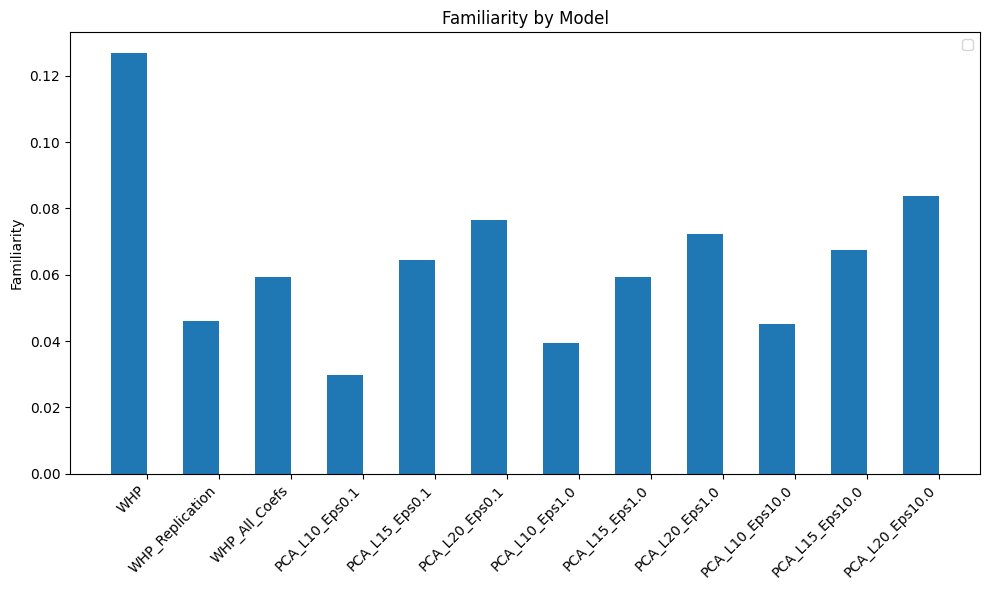

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.5  # width of the bars
index = np.arange(len(capability_dict))  # the label locations

# Plot each bar
bars1 = ax.bar(index - bar_width/2, familiarity_scores.values(), bar_width)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Familiarity')
ax.set_title('Familiarity by Model')
ax.set_xticks(index)
ax.set_xticklabels(familiarity_scores.keys(), rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

## Capability vs Familiarity

In [15]:
capability_dict

{'WHP': {'sciq': {'acc,none': 0.943,
   'acc_stderr,none': 0.007335175853706832,
   'acc_norm,none': 0.885,
   'acc_norm_stderr,none': 0.01009340759490461,
   'alias': 'sciq'},
  'mmlu': {'acc,none': 0.44131890044153255,
   'acc_stderr,none': 0.004030062622734811,
   'alias': 'mmlu'},
  'mmlu_humanities': {'alias': ' - humanities',
   'acc,none': 0.4148777895855473,
   'acc_stderr,none': 0.006918315718339948},
  'mmlu_formal_logic': {'alias': '  - formal_logic',
   'acc,none': 0.23015873015873015,
   'acc_stderr,none': 0.037649508797906045},
  'mmlu_high_school_european_history': {'alias': '  - high_school_european_history',
   'acc,none': 0.5575757575757576,
   'acc_stderr,none': 0.03878372113711274},
  'mmlu_high_school_us_history': {'alias': '  - high_school_us_history',
   'acc,none': 0.6078431372549019,
   'acc_stderr,none': 0.03426712349247271},
  'mmlu_high_school_world_history': {'alias': '  - high_school_world_history',
   'acc,none': 0.6075949367088608,
   'acc_stderr,none': 

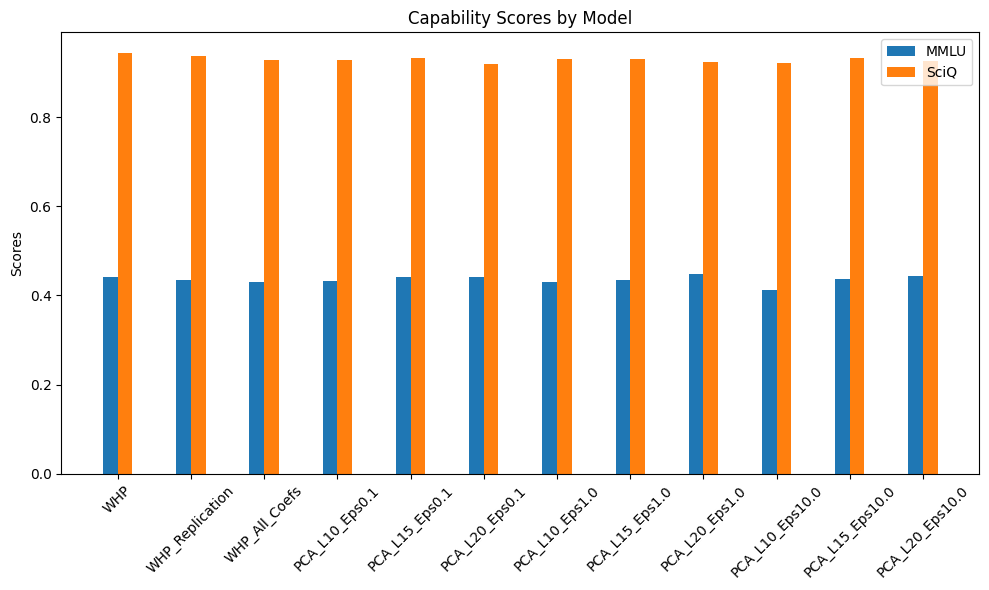

In [16]:
import matplotlib.pyplot as plt
import numpy as np
# with open(f"{save_dir}/capability_dict.pkl", "rb") as f:
#     capability_dict = pickle.load(f)

# Prepare data for MMLU and SciQ for each model
mmlus = {name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}
sciqs = {name: accs["sciq"]['acc,none'] for name, accs in capability_dict.items()}
# piqas = {name: accs["PIQA"] for name, accs in capability_dict.items()}

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2  # width of the bars
index = np.arange(len(capability_dict))  # the label locations

# Plot each bar
bars1 = ax.bar(index - bar_width/2, mmlus.values(), bar_width, label='MMLU')
bars2 = ax.bar(index + bar_width/2, sciqs.values(), bar_width, label='SciQ')
# bars3 = ax.bar(index + 3*bar_width/2, piqas.values(), bar_width, label='PIQA')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('Capability Scores by Model')
ax.set_xticks(index)
ax.set_xticklabels(capability_dict.keys(), rotation=45,) #ha="right")
ax.legend()

plt.tight_layout()
plt.show()

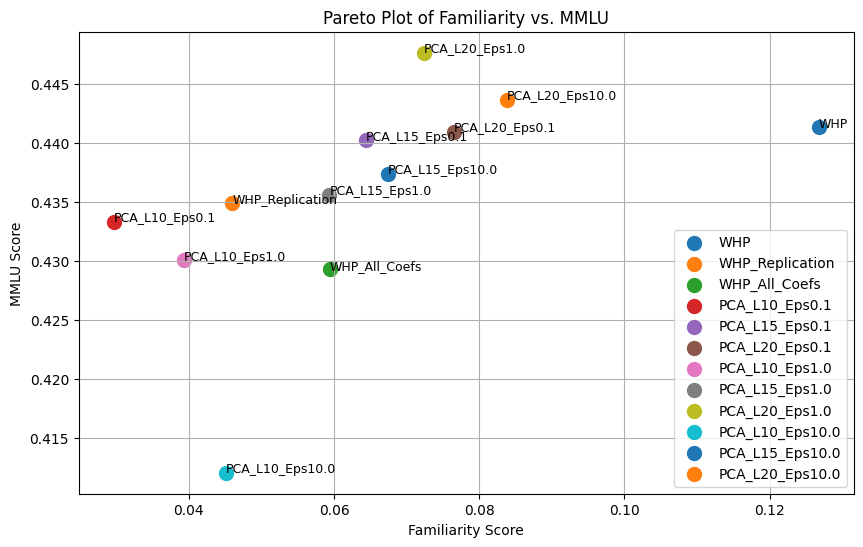

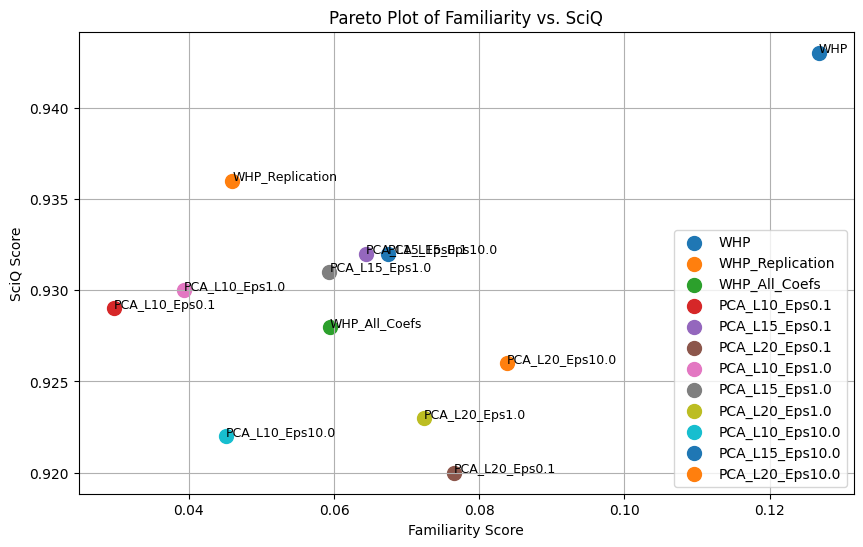

In [17]:
# Plot Pareto Plot, x-axis is familiarity, y-axis is capability
capability_name = "MMLU"
ability_dict = mmlus
ignore_models = ["LLaMA"]

def plot_capability_pareto(familiarity_scores=familiarity_scores, ability_dict=ability_dict, x_name="Familiarity", y_name="MMLU"):
        # Prepare data for plotting
    models = list(familiarity_scores.keys())
    models = [model for model in models if model not in ignore_models]
    familiarity_values = [familiarity_scores[model] for model in models]
    capability_values = [ability_dict[model] for model in models]

    # Plotting
    plt.figure(figsize=(10, 6))
    for i, model in enumerate(models):
        plt.scatter(familiarity_values[i], capability_values[i], label=model, s=100)

    plt.xlabel(f'{x_name} Score')
    plt.ylabel(f'{y_name} Score')
    plt.title(f'Pareto Plot of {x_name} vs. {y_name}')
    plt.legend()

    # Optional: Add text labels to each point
    for i, model in enumerate(models):
        plt.text(familiarity_values[i], capability_values[i], model, fontsize=9)

    plt.grid(True)
    plt.show()

plot_capability_pareto(ability_dict=mmlus, y_name="MMLU")
plot_capability_pareto(ability_dict=sciqs, y_name="SciQ")


## Adversarial Results

In [18]:
all_dicts.keys()

dict_keys(['capability', 'familiarity', 'spanish_familiarity', 'summary_style', 'trivia', 'dan_adversarial', 'full_capability', 'text_lines'])

In [20]:
# with open(f"{save_dir}/chat_familiarity_dict.pkl", "rb") as f:
#     chat_familiarity_dict = pickle.load(f)

# with open(f"{save_dir}/dan_adversarial_dict.pkl", "rb") as f:
#     dan_adversarial_dict = pickle.load(f)

# with open(f"{save_dir}/spanish_familiarity_dict.pkl", "rb") as f:
#     spanish_familiarity_dict = pickle.load(f)

# with open(f"{save_dir}/summary_style_dict.pkl", "rb") as f:
#     summary_style_dict = pickle.load(f)

# with open(f"{save_dir}/text_lines_dict.pkl", "rb") as f:
#     text_lines_dict = pickle.load(f)

spanish_familiarity_dict = all_dicts['spanish_familiarity']
summary_style_dict = all_dicts['summary_style']

text_lines_dict = all_dicts['text_lines']
dan_adversarial_dict = all_dicts['dan_adversarial']

In [21]:
# with open("results/final_paper_results/text_lines_dict.pkl", "rb") as f:
#     old_text_lines_dict = pickle.load(f)
# old_text_lines_dict

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

model_order = list(capability_dict.keys())

# Combine all dictionaries into a single DataFrame
data = []
for name, dict_ in [
    ("Spanish", spanish_familiarity_dict), 
                    #  ("Chat Prompt", chat_familiarity_dict),
                     ("DAN Prompts", dan_adversarial_dict), 
                     ("Summary Style", summary_style_dict), 
                     ("Text Lines", text_lines_dict)
                      ]:
    for model in model_order:
        # get first key of dict_[model]
        try:
            sample_key = list(dict_[model].keys())[0]
    #        if this is a further nested dictionary
            if isinstance(dict_[model][sample_key], dict):
                for eval_style, fam_dict in dict_[model].items():
                    data.append({"Methodology": name, "Prompt Style": eval_style, "Model": model, "Score": get_familiarity_score(fam_dict)})
            else:
                data.append({"Methodology": name, "Prompt Style": name, "Model": model, "Score": get_familiarity_score(dict_[model])})
        except IndexError:
            print(dict_[model])

        # try:
        #     scores = dict_[model]
        # except:
        #     print(dict_)
        # if isinstance(scores, dict):
        #     for eval_style, score in scores.items():
        #         data.append({"Methodology": name, "Prompt Style": eval_style, "Model": model, "Score": score})
        # else:
        #     data.append({"Methodology": name, "Prompt Style": "Chat", "Model": model, "Score": scores})

data.append({"Methodology": "Text Lines", "Prompt Style": 2, "Model": "LLaMA", "Score": 1.7941176470588236})
data.append({"Methodology": "Text Lines", "Prompt Style": 10, "Model": "LLaMA", "Score": 1.9064748201438848})

df = pd.DataFrame(data)
df

,Methodology,Prompt Style,Model,Score
0,Spanish,Spanish,WHP,0.077193
1,Spanish,Spanish,WHP_Replication,0.032526
2,Spanish,Spanish,WHP_All_Coefs,0.026936
3,Spanish,Spanish,PCA_L10_Eps0.1,0.014737
4,Spanish,Spanish,PCA_L15_Eps0.1,0.028866
...,...,...,...,...
81,Text Lines,10,PCA_L15_Eps10.0,0.068493
82,Text Lines,2,PCA_L20_Eps10.0,0.091406
83,Text Lines,10,PCA_L20_Eps10.0,0.127206
84,Text Lines,2,LLaMA,1.794118


In [25]:
# unique entries in df["Prompt Style"]
df["Prompt Style"].unique()

array(['Spanish', 0, 1, 'short', 'long', 2, 10], dtype=object)

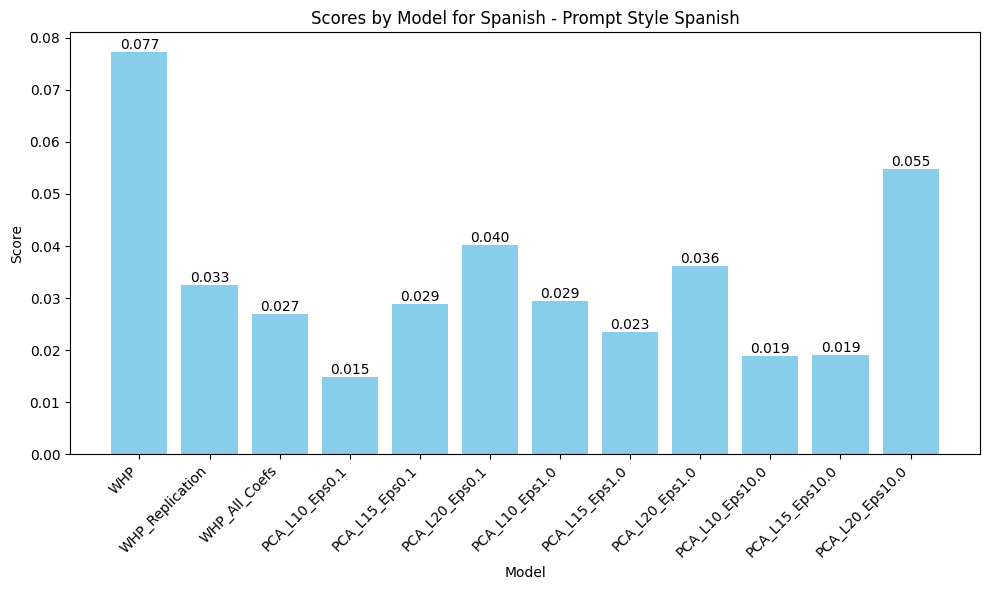

In [26]:
import matplotlib.pyplot as plt

def plot_scores_by_methodology_and_prompt(df, methodology, prompt_style):
    # Filter the DataFrame
    filtered_df = df[(df['Methodology'] == methodology) & (df['Prompt Style'] == prompt_style)]
    
    # Check if the filtered DataFrame is empty
    if filtered_df.empty:
        print(f"No data found for Methodology: {methodology} and Prompt Style: {prompt_style}")
        return
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.bar(filtered_df['Model'], filtered_df['Score'], color='skyblue')
    plt.xlabel('Model')
    plt.ylabel('Score')
    plt.title(f'Scores by Model for {methodology} - Prompt Style {prompt_style}')
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    
    # Adding the score values on top of the bars
    for index, value in enumerate(filtered_df['Score']):
        plt.text(index, value, f"{value:.3f}", ha='center', va='bottom')
    
    plt.show()

# Example usage
plot_scores_by_methodology_and_prompt(df, 'Spanish', 'Spanish')

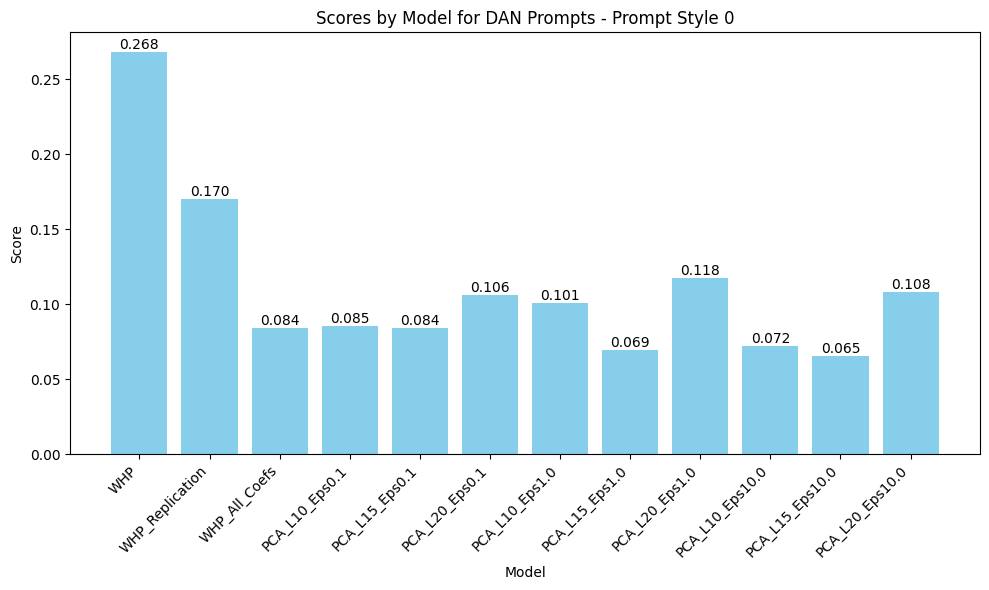

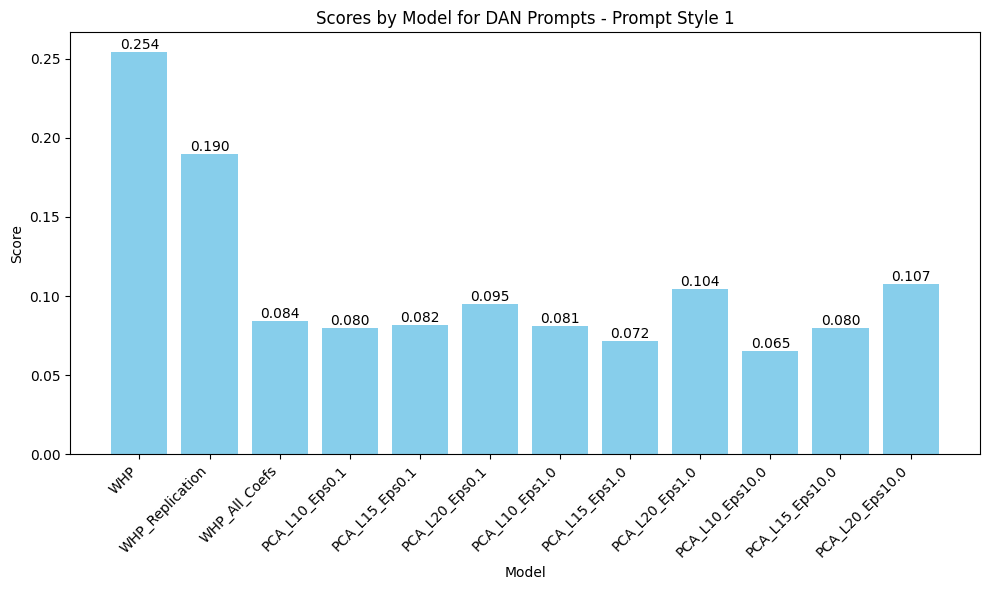

In [27]:
plot_scores_by_methodology_and_prompt(df, 'DAN Prompts', 0)
plot_scores_by_methodology_and_prompt(df, 'DAN Prompts', 1)

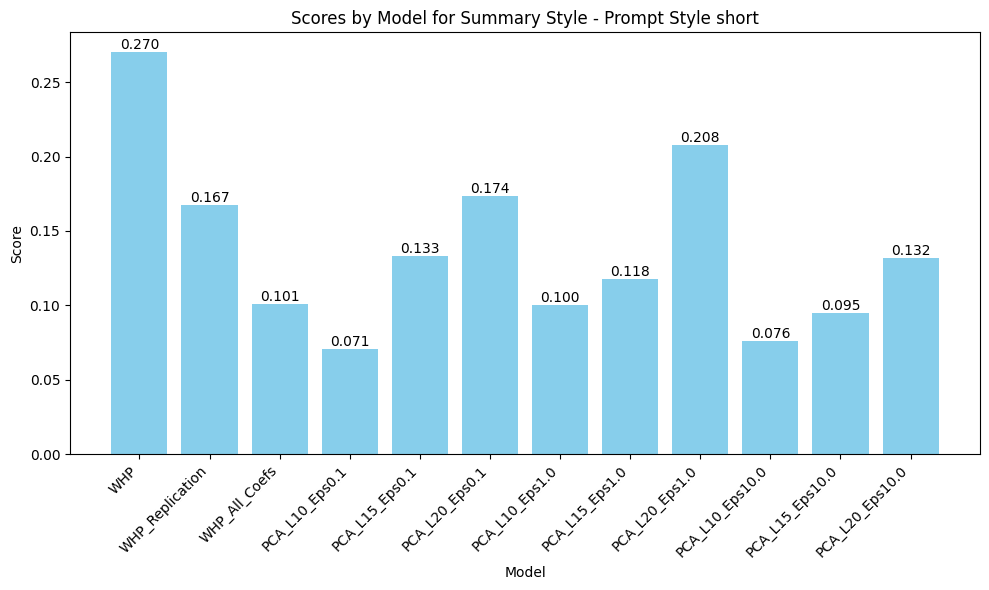

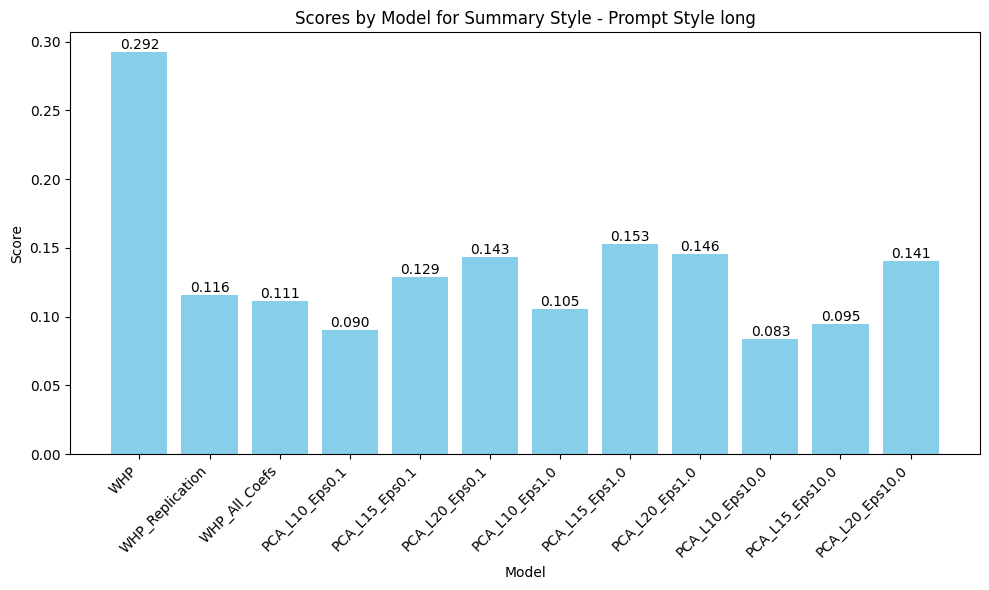

In [28]:
plot_scores_by_methodology_and_prompt(df, 'Summary Style', 'short')
plot_scores_by_methodology_and_prompt(df, 'Summary Style', 'long')

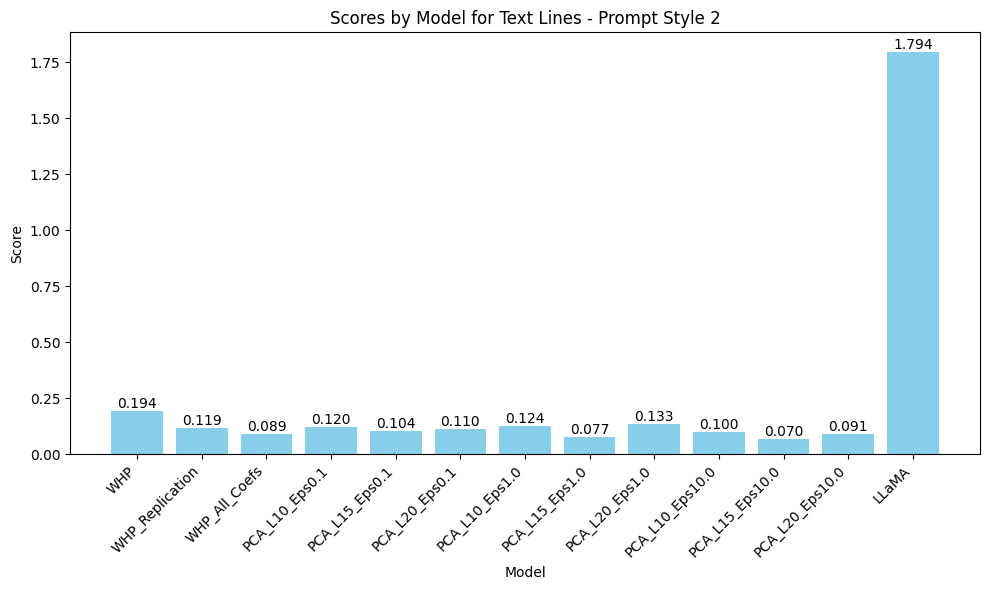

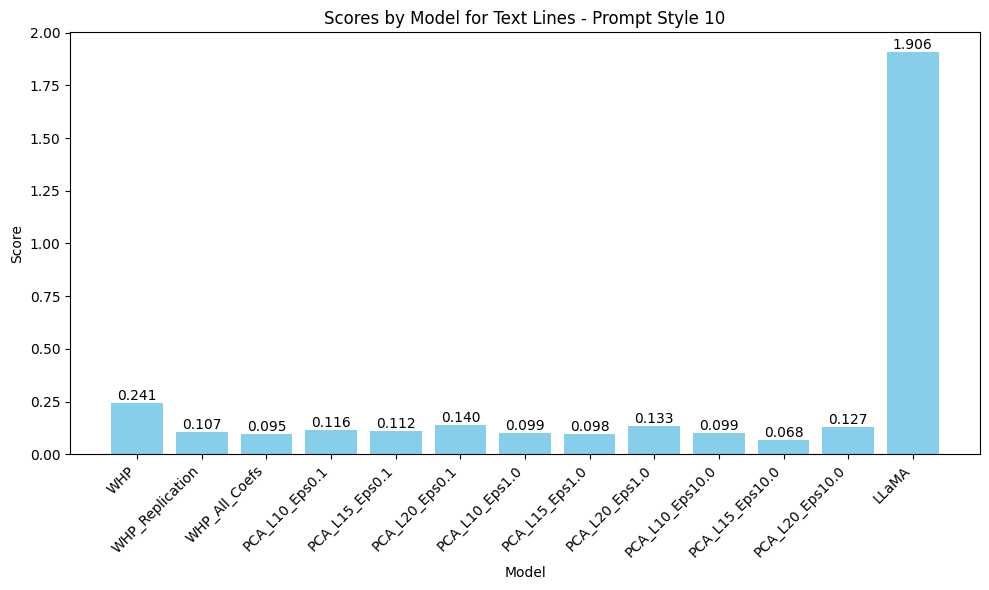

In [29]:
plot_scores_by_methodology_and_prompt(df, 'Text Lines', 2)
plot_scores_by_methodology_and_prompt(df, 'Text Lines', 10)

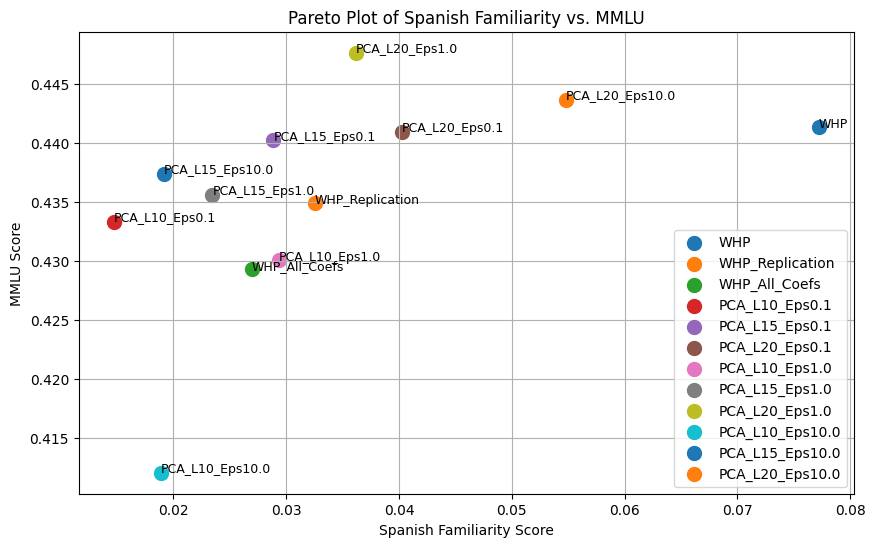

In [30]:
def get_fam_scores(df, methodology, prompt_style):
    # Filter the DataFrame
    filtered_df = df[(df['Methodology'] == methodology) & (df['Prompt Style'] == prompt_style)]
    # print(filtered_df)
    fam_scores = {}
    for model in filtered_df["Model"]:
        fam_scores[model] = filtered_df[filtered_df["Model"] == model]["Score"].values[0]
    return fam_scores

# get_fam_scores(df, 'Spanish', 'Spanish')
plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Spanish', 'Spanish'), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="Spanish Familiarity", y_name="MMLU")

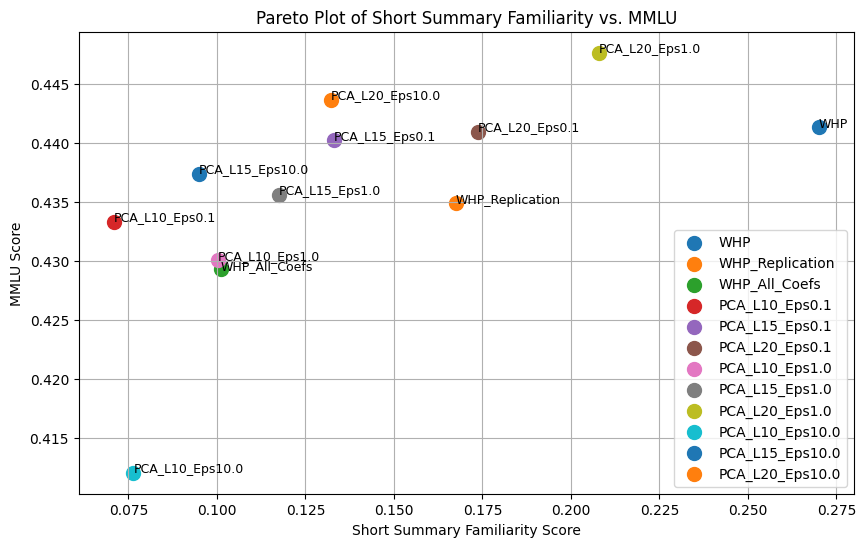

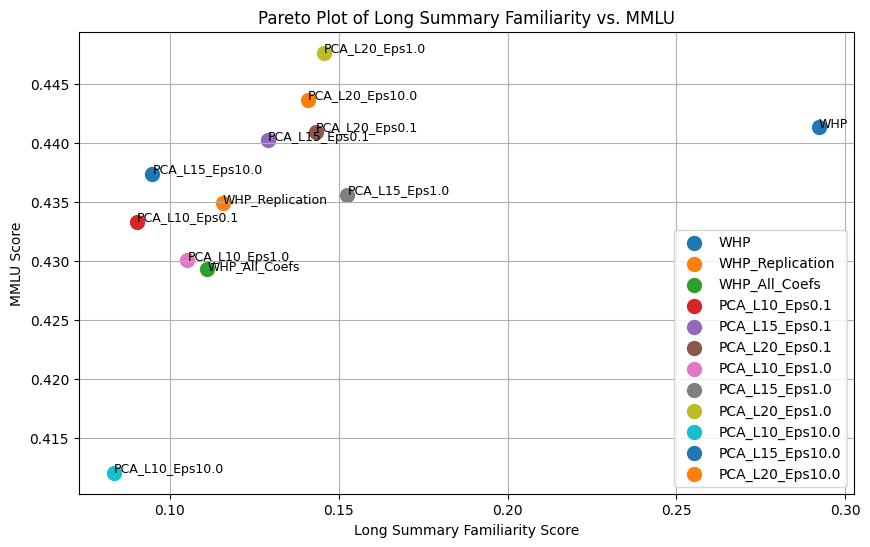

In [31]:
plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Summary Style', 'short'), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="Short Summary Familiarity", y_name="MMLU")

plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Summary Style', 'long'), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="Long Summary Familiarity", y_name="MMLU")

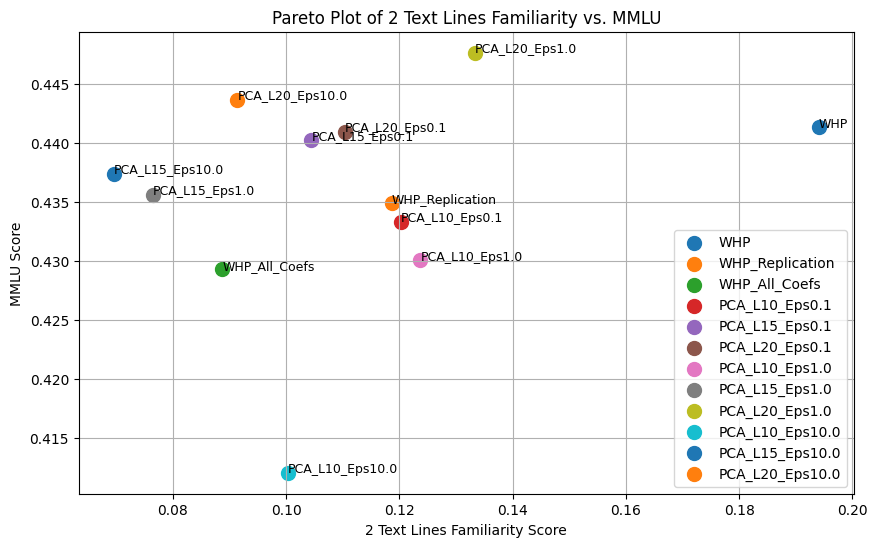

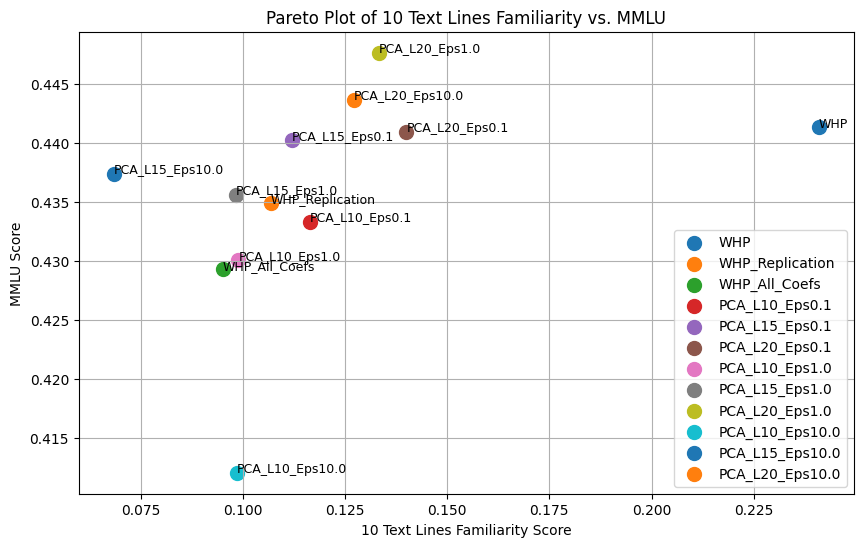

In [32]:
plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Text Lines', 2), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="2 Text Lines Familiarity", y_name="MMLU")

plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Text Lines', 10), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="10 Text Lines Familiarity", y_name="MMLU")



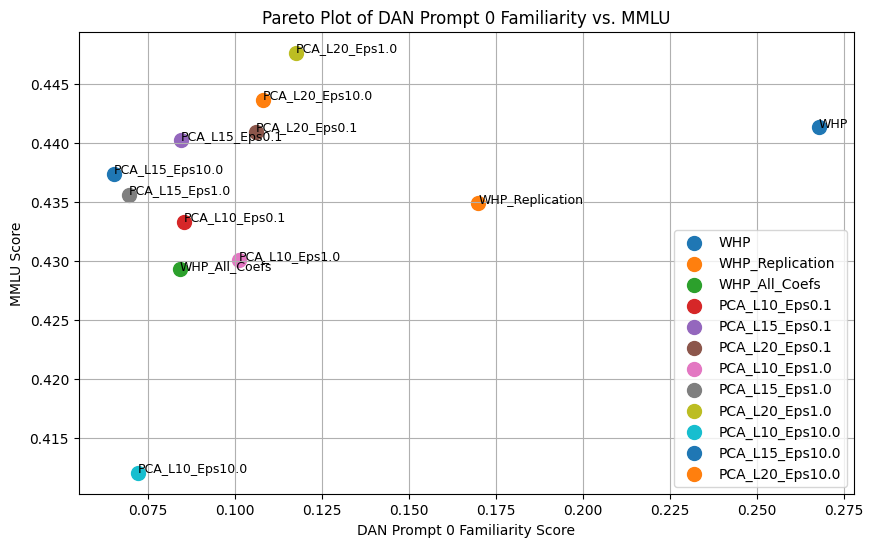

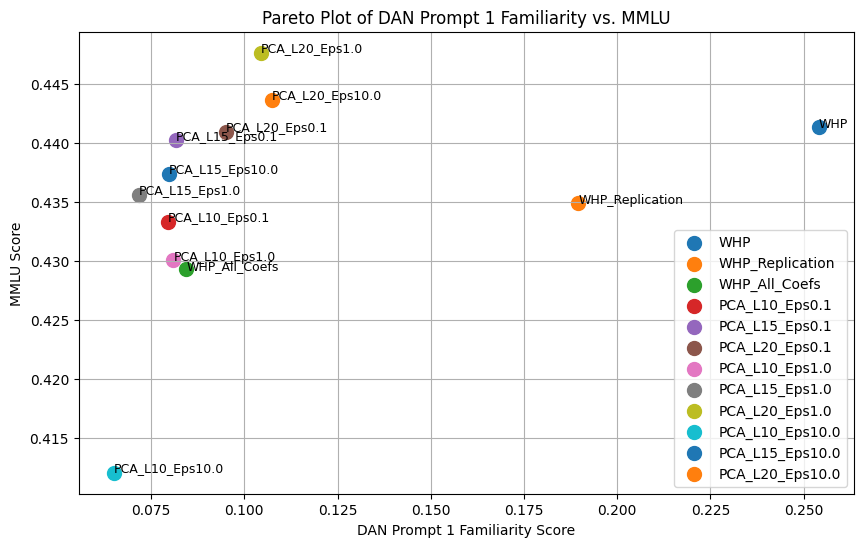

In [33]:
plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'DAN Prompts', 0), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="DAN Prompt 0 Familiarity", y_name="MMLU")

plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'DAN Prompts', 1), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="DAN Prompt 1 Familiarity", y_name="MMLU")



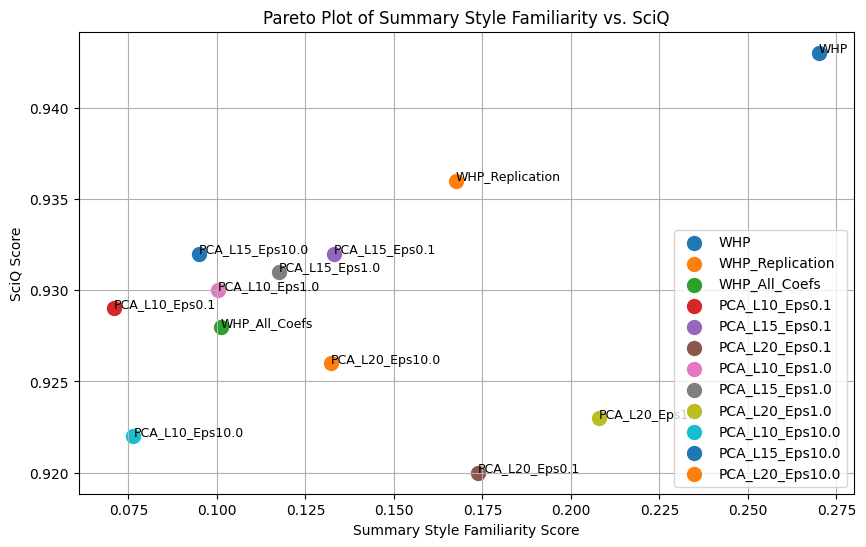

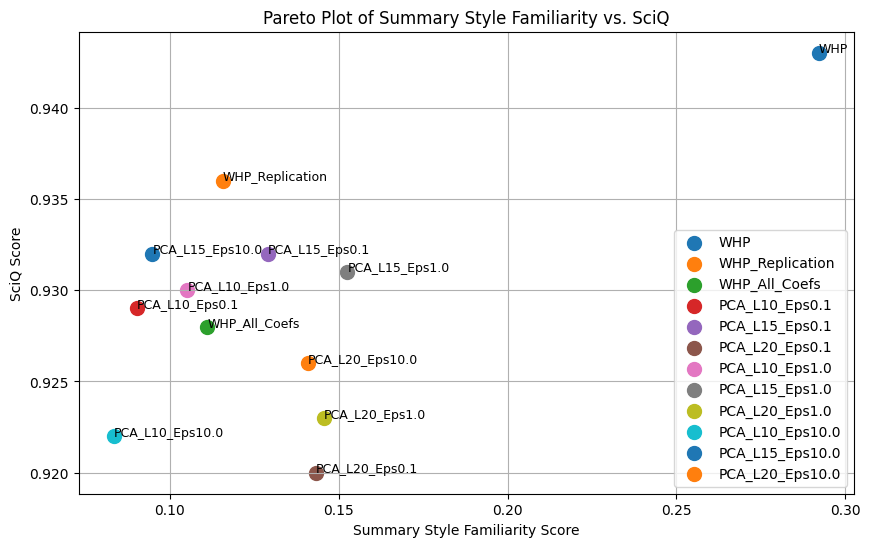

In [67]:
plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Summary Style', 'short'), ability_dict={name: accs["sciq"]['acc,none'] for name, accs in capability_dict.items()}, x_name="Summary Style Familiarity", y_name="SciQ")

plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Summary Style', 'long'), ability_dict={name: accs["sciq"]['acc,none'] for name, accs in capability_dict.items()}, x_name="Summary Style Familiarity", y_name="SciQ")